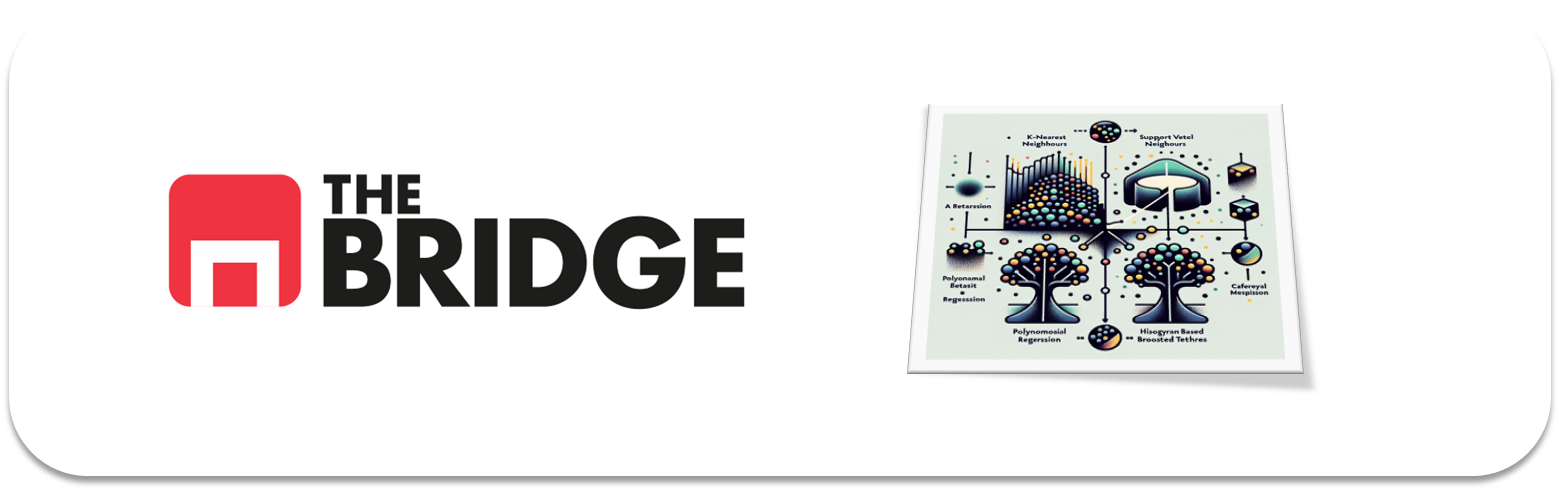

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [28]:
import pandas as pd
import numpy as np
import bootcampviztools as bt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt



### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [4]:
df = pd.read_csv("./data/credit_npo.csv")

In [5]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [6]:
df.shape

(12537, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Tras revisar el `describe()`, observo que casi todas las variables son numéricas, pero algunas tienen valores atípicos muy extremos. También hay valores nulos en `MonthlyIncome` y `NumberOfDependents` que trataremos más adelante.

La variable objetivo (target) es `SeriousDlqin2yrs`, que indica si hay morosidad grave (1) o no (0). Vamos a ver su distribución.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

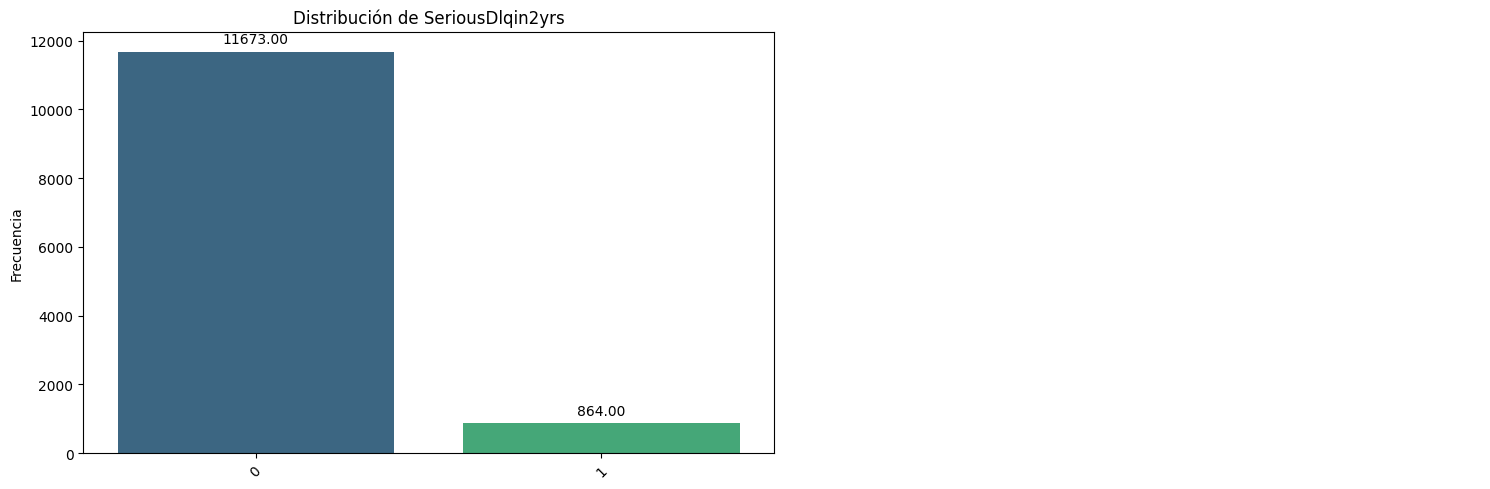

In [11]:
target = "SeriousDlqin2yrs"

bt.pinta_distribucion_categoricas(df,[target], mostrar_valores= True, relativa=False)

El target está muy desbalanceado (aprox 93% vs 7%). Antes de tratar los nulos o escalar, separamos en *train* y *test*. Usamos `stratify` para mantener la proporción de la clase minoritaria en ambos conjuntos.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

#### Train/Test

In [14]:
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42, stratify = df[target])

#### Limpieza

- Para `NumberOfDependents`, al ser una variable discreta que representa número de personas, usaremos la moda (el valor más frecuente).
- Para `MonthlyIncome`, como hemos visto que tiene muchos outliers en la cola superior, la media se vería distorsionada, así que imputamos usando la mediana.

In [15]:
ndp = "NumberOfDependents"
mi = "MonthlyIncome"

# Imputamos moda en dependientes
moda_train = train_set[ndp].mode()[0]
train_set[ndp] = train_set[ndp].fillna(moda_train)
test_set[ndp] = test_set[ndp].fillna(moda_train)

# Imputamos mediana en ingresos
mediana_train = train_set[mi].median()
train_set[mi] = train_set[mi].fillna(mediana_train)
test_set[mi] = test_set[mi].fillna(mediana_train)

Dado que debemos usar **KNN** es necesario que las variables estén en la misma escala porque este algoritmo tira de distancias.
Además, como hay distribuciones muy sesgadas, así que aplicamos una transformación logarítmica `log(x+1)` a todas las features (excepto la edad) antes de estandarizarlas. 

In [17]:
features = [col for col in train_set.columns if col != target]

train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

# Transformación logarítmica
for col in features:
    if col != "age":
        train_set_scaled[col] = np.log(train_set_scaled[col] + 1)
        test_set_scaled[col] = np.log(test_set_scaled[col] + 1)

# Escalado estándar
scaler = StandardScaler()
train_set_scaled[features] = scaler.fit_transform(train_set_scaled[features])
test_set_scaled[features] = scaler.transform(test_set_scaled[features])

# Generamos finalmente nuestra X e y (escaladas y sin escalar)
X_train = train_set[features]
X_train_scaled = train_set_scaled[features]
y_train = train_set[target]

X_test = test_set[features]
X_test_scaled = test_set_scaled[features]
y_test = test_set[target]

#### Visualización de relaciones con mi target

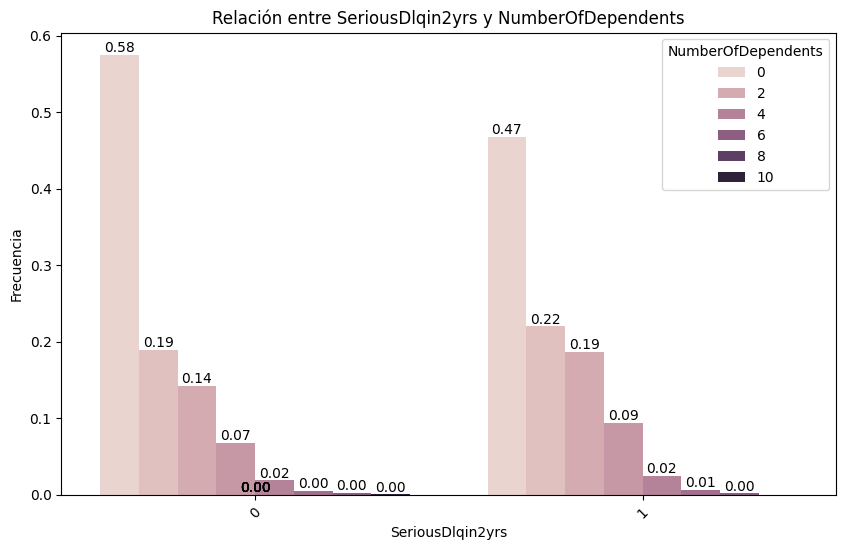

In [18]:
bt.plot_categorical_relationship_fin(train_set, target, ndp, show_values= True, relative_freq= True)

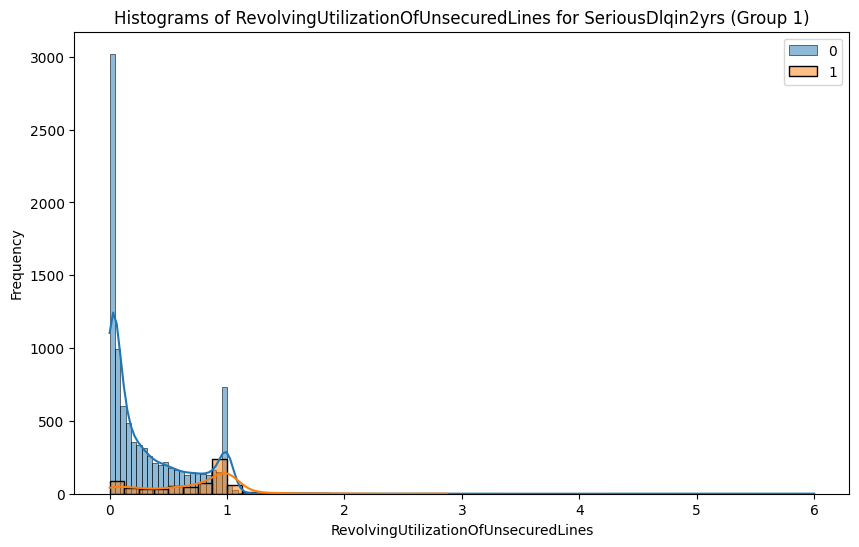

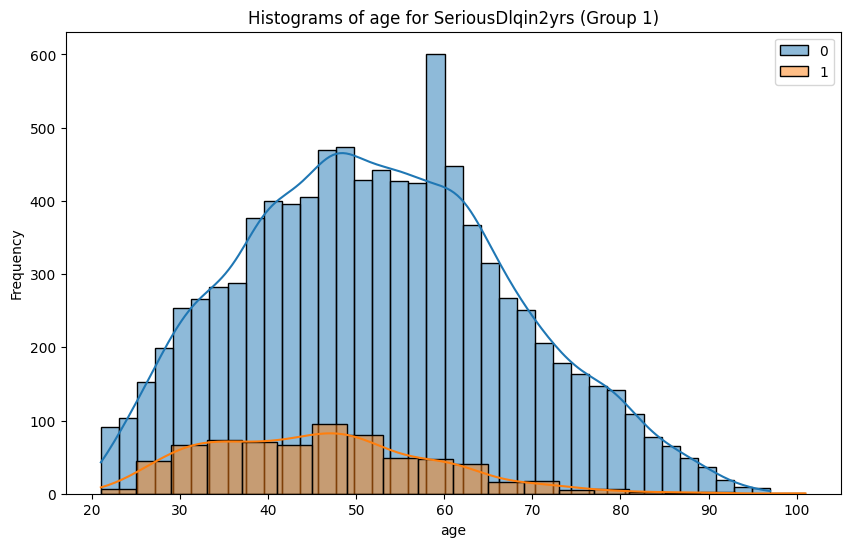

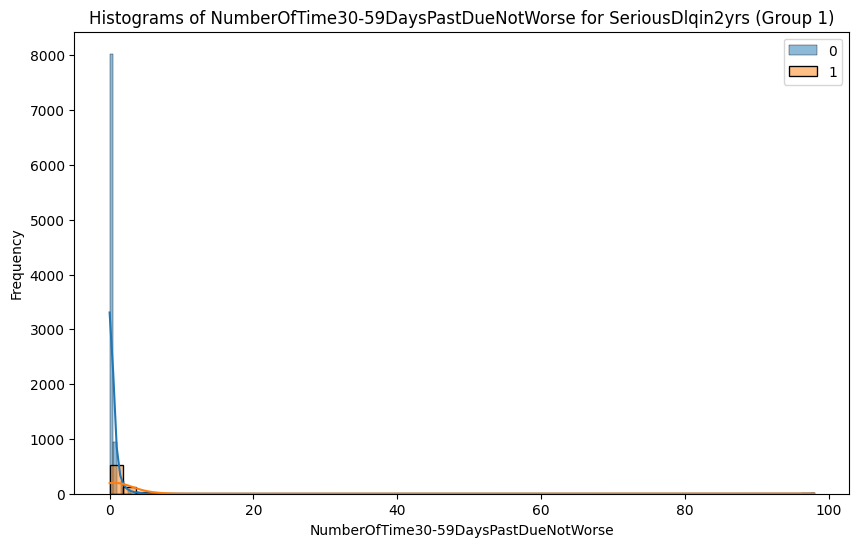

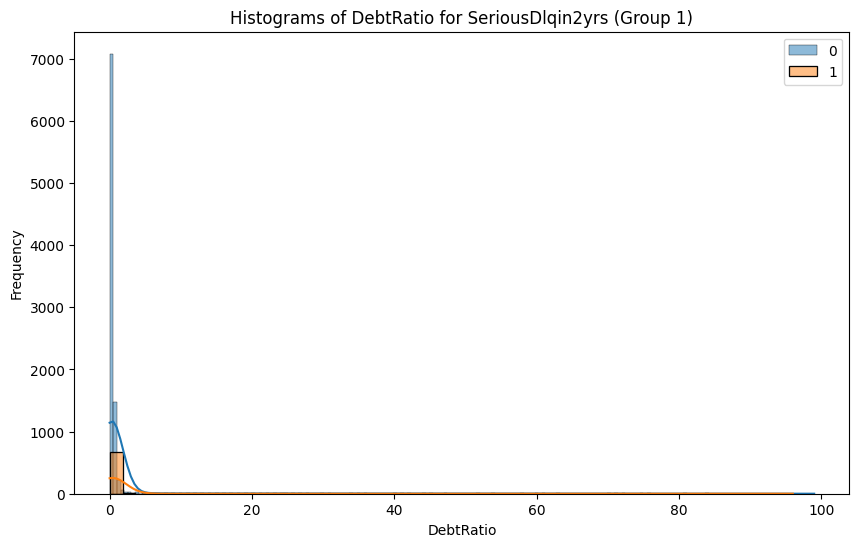

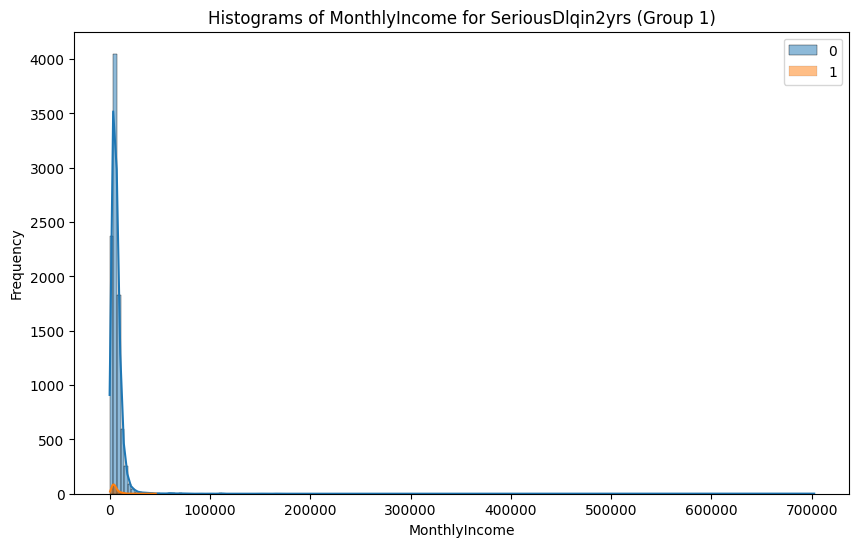

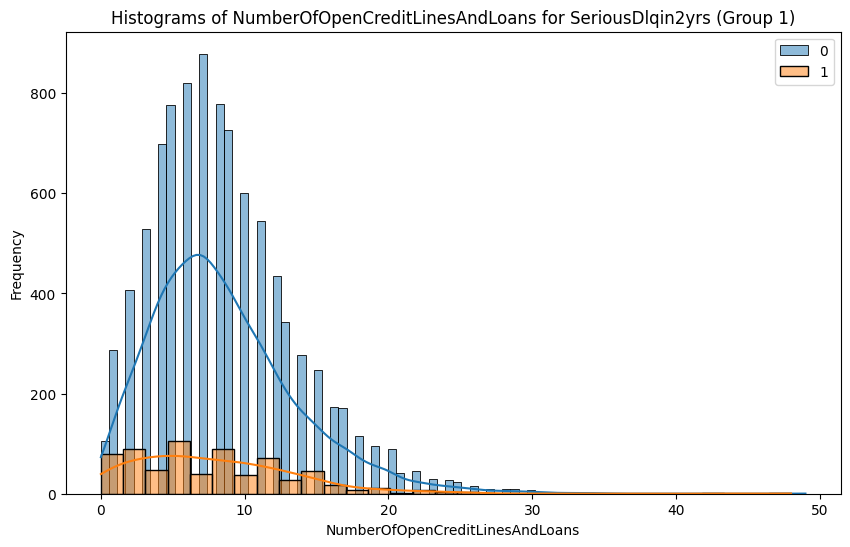

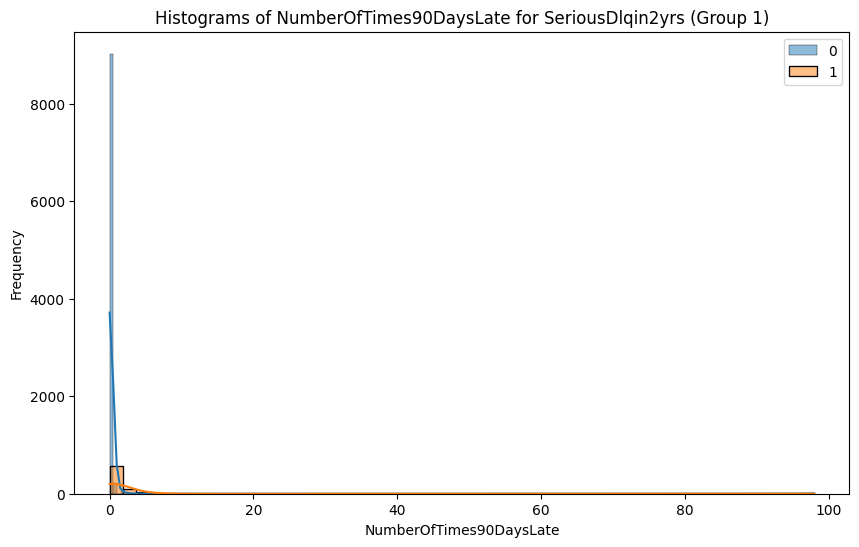

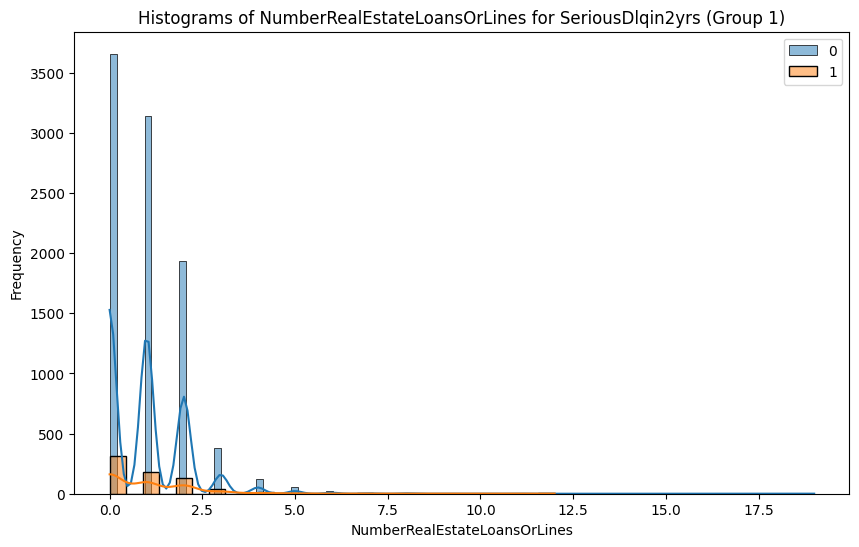

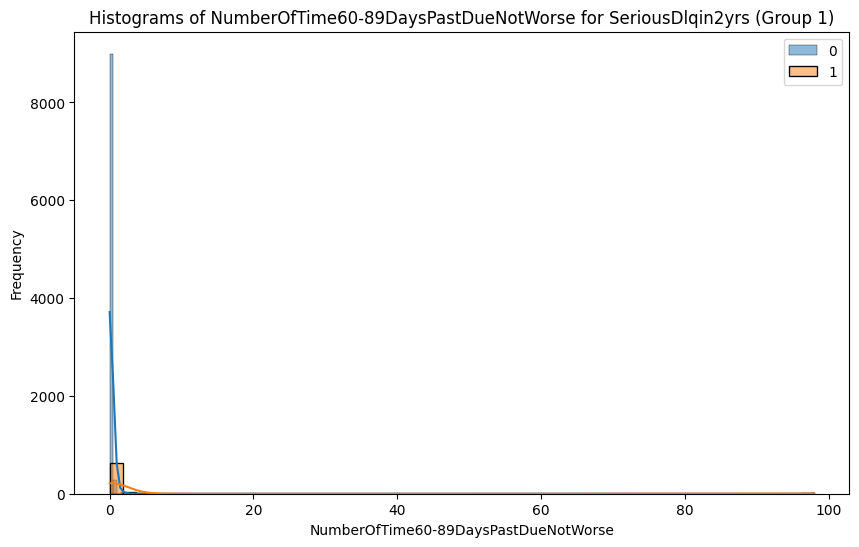

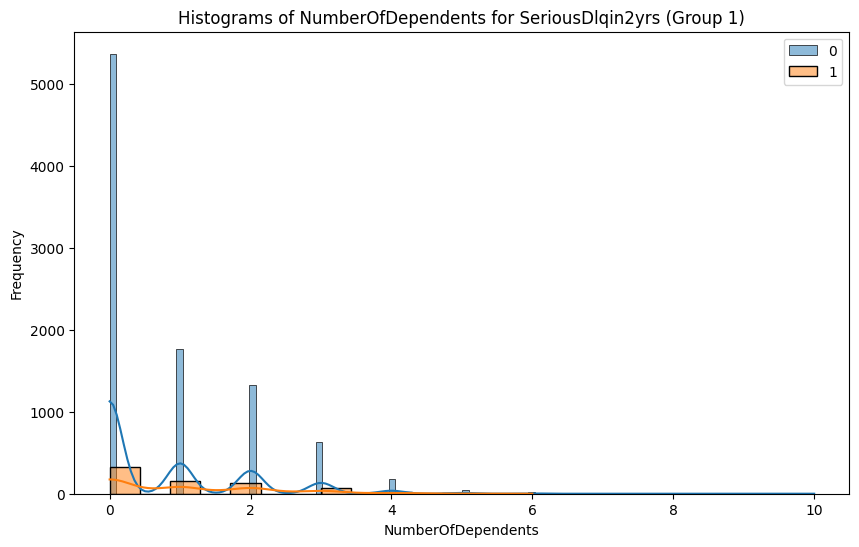

In [19]:
features = [col for col in train_set.columns if col != target]

for col in features:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 2)

#### Comparativa de modelos 

In [21]:
modelos = ["KNN", "Logistic", "RandomF", "XGBoost", "LightGBM"]

knn_clf = KNeighborsClassifier(n_neighbors=7) # Probamos k=7
lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose=-1, n_jobs=-1)

print("--- Balanced Accuracy en Cross Validation ---")
for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    if nombre in ["KNN", "Logistic"]:
        score = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy"))
    print(f"Para {nombre}: {score:.4f}")

--- Balanced Accuracy en Cross Validation ---
Para KNN: 0.5739
Para Logistic: 0.5621
Para RandomF: 0.5530
Para XGBoost: 0.5982
Para LightGBM: 0.5940


Las métricas iniciales rondan el 0.55 - 0.60, lo cual es bajo. Esto se debe al fuerte desequilibrio de clases. Vamos a intentar mitigarlo utilizando el hiperparámetro de balanceo propio de cada modelo (`class_weight='balanced'` o `scale_pos_weight`) y probando de nuevo.

In [22]:
# Actualizamos los modelos con balanceo interno
knn_clf = KNeighborsClassifier(n_neighbors=7, weights="distance") # A KNN le damos peso por distancia
lr_clf = LogisticRegression(max_iter=10000, class_weight="balanced")
rf_clf = RandomForestClassifier(max_depth=5, random_state=42, class_weight="balanced")
xgb_clf = XGBClassifier(max_depth=5, random_state=42, scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])))
lgb_clf = LGBMClassifier(max_depth=5, verbose=-1, random_state=42, class_weight="balanced", n_jobs=-1)

print("--- Balanced Accuracy con Class Weight ---")
for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lgb_clf]):
    if nombre in ["KNN", "Logistic"]:
        score = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy"))
    print(f"Para {nombre}: {score:.4f}")

--- Balanced Accuracy con Class Weight ---
Para KNN: 0.5748
Para Logistic: 0.7722
Para RandomF: 0.7643
Para XGBoost: 0.6757
Para LightGBM: 0.7442


Vemos una mejora significativa en algunos modelos como la Regresión Logística, Random Forest y LightGBM (que roza el 0.74). Como **LightGBM** es rápido y nos ha dado muy buen resultado consistenemente, voy a seleccionarlo como mi modelo ganador para hacerle ajuste de hiperparámetros.

In [25]:
# GridSearch para el modelo elegido (LightGBM)
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.1, 0.5, 1],
    "max_depth": [5, 10, 15],
    "min_data_in_leaf": [10, 20, 100],
    "class_weight": ["balanced", None]
}

lgb_grid = GridSearchCV(LGBMClassifier(verbose=-1, random_state=42),
                        param_grid=param_grid,
                        cv=5,
                        scoring="balanced_accuracy",
                        n_jobs=-1)

lgb_grid.fit(X_train, y_train)

print("Mejores parámetros:", lgb_grid.best_params_)
print("Mejor CV Score:", lgb_grid.best_score_)

Mejores parámetros: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': 5, 'min_data_in_leaf': 100, 'n_estimators': 100}
Mejor CV Score: 0.7558565094768038


#### Evaluación final

In [27]:
best_model = lgb_grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Reporte de clasificación en Test:")
print(classification_report(y_test, y_pred))

Reporte de clasificación en Test:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      2335
           1       0.24      0.72      0.36       173

    accuracy                           0.82      2508
   macro avg       0.61      0.78      0.63      2508
weighted avg       0.93      0.82      0.86      2508



#### Análisis de errores

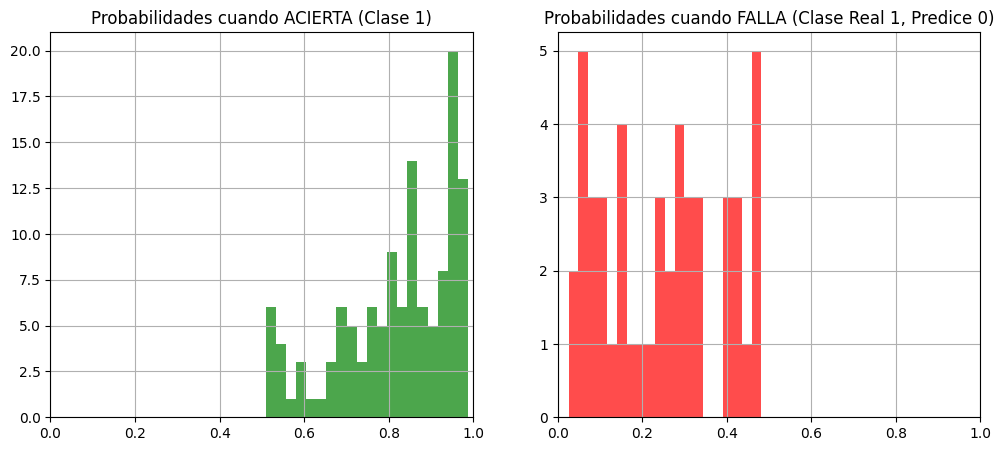

In [29]:
# Obtenemos las probabilidades de clase 1
y_proba = best_model.predict_proba(X_test)[:, 1]

error_df = pd.DataFrame({
    'Real': y_test,
    'Prediccion': y_pred,
    'Probabilidad_1': y_proba
})

# Filtros
es_clase_1 = error_df['Real'] == 1
bien_clasificado = error_df['Real'] == error_df['Prediccion']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de cuando acierta que es 1
error_df[es_clase_1 & bien_clasificado]['Probabilidad_1'].hist(ax=ax[0], bins=20, color='green', alpha=0.7)
ax[0].set_title("Probabilidades cuando ACIERTA (Clase 1)")
ax[0].set_xlim(0, 1)

# Histograma de cuando se equivoca y dice que es 0 siendo 1
error_df[es_clase_1 & ~bien_clasificado]['Probabilidad_1'].hist(ax=ax[1], bins=20, color='red', alpha=0.7)
ax[1].set_title("Probabilidades cuando FALLA (Clase Real 1, Predice 0)")
ax[1].set_xlim(0, 1)

plt.show()

Analizamos las probabilidades predichas para entender dónde falla el modelo. Nos fijaremos en las observaciones de la clase 1 (impagadores). Queremos ver la confianzaque da el modelo cuando acierta vs cuando se equivoca en esta clase minoritaria. Y lo wque vemos es que, cuando el modelo acierta, lo hace con una probabilidad muy alta. Sin embargo, cuando falla, las probabilidades están muy repartidas en la zona de incertidumbre. En el futuro podríamos plantearnos bajar el umbral de probabilidad de 0.5 a un número más bajo (por ejemplo 0.30) si de cara a negocio nos importa muchísimo capturar a los impagadores.